# LTR Model Comparison — Pointwise vs RankNet vs LambdaRank
### Statistical comparison across all three Learning-to-Rank modes
---
**Dataset**: LETOR4 (MQ2008)  
**Evaluation**: 5-Fold (Standard LETOR Folds), 3 seeds each  
**Significance**: Paired t-test


## Step 1 · Setup & Load Pre-computed Results

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Pairwise Approaches", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Pairwise Approaches")


Repo cloned.
ltr package installed.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ltr.metrics import paired_significance

RESULTS_DIR = "/content/Learning-To-Rank-for-Search/Pairwise Approaches/ltr_results"
K_LIST = [1, 3, 5, 10]

def load_results(mode: str) -> dict:
    path = f"{RESULTS_DIR}/{mode}_results.json"
    with open(path) as f:
        return json.load(f)

pointwise_results   = load_results("pointwise")
ranknet_results     = load_results("ranknet")
lambdarank_results  = load_results("lambdarank")
lambdamart_results  = load_results("lambdamart")

print("Results loaded successfully.")
print(f"  Pointwise   folds: {len(pointwise_results['fold_results'])}")
print(f"  RankNet     folds: {len(ranknet_results['fold_results'])}")
print(f"  LambdaRank  folds: {len(lambdarank_results['fold_results'])}")


Results loaded successfully.
  Pointwise   folds: 5
  RankNet     folds: 5
  LambdaRank  folds: 5


## Step 2 · Summary Table — Mean ± Std Across All Folds × Seeds

In [12]:
def print_comparison_table(results_dict: dict, k_list=None):
    """Print a comparison table with Mean ± Std for each model and k."""
    if k_list is None:
        k_list = K_LIST

    models = {
        "Pointwise":  results_dict["pointwise"],
        "RankNet":    results_dict["ranknet"],
        "LambdaRank": results_dict["lambdarank"],
        "LambdaMART": results_dict["lambdamart"],
    }

    print(f"\n{'═'*90}")
    print(f"  MODEL COMPARISON — NDCG (Mean ± Std over 5 folds × 3 seeds)")
    print(f"{'═'*90}")
    header = f"{'Metric':<15}"
    for name in models:
        header += f"{name:<20}"
    print(header)
    print(f"{'─'*90}")

    for k in k_list:
        row = f"NDCG@{k:<5}"
        for name, res in models.items():
            # overall is keyed by string k (JSON) or int k
            overall = res.get("overall", {})
            entry = overall.get(str(k), overall.get(k, {"mean": 0.0, "std": 0.0}))
            row += f"  {entry['mean']:.4f} ± {entry['std']:.4f}   "
        print(row)
    print(f"{'═'*70}")

results_dict = {
    "pointwise":  pointwise_results,
    "ranknet":    ranknet_results,
    "lambdarank": lambdarank_results,
    "lambdamart": lambdamart_results,
}

print_comparison_table(results_dict)



══════════════════════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON — NDCG (Mean ± Std over 5 folds × 3 seeds)
══════════════════════════════════════════════════════════════════════════════════════════
Metric         Pointwise           RankNet             LambdaRank          LambdaMART          
──────────────────────────────────────────────────────────────────────────────────────────
NDCG@1      0.3594 ± 0.0291     0.3690 ± 0.0341     0.3641 ± 0.0275     0.3432 ± 0.0318   
NDCG@3      0.4016 ± 0.0363     0.4084 ± 0.0406     0.4043 ± 0.0348     0.3898 ± 0.0357   
NDCG@5      0.4473 ± 0.0339     0.4526 ± 0.0375     0.4516 ± 0.0322     0.4344 ± 0.0396   
NDCG@10     0.4949 ± 0.0355     0.4993 ± 0.0406     0.4974 ± 0.0371     0.4846 ± 0.0377   
══════════════════════════════════════════════════════════════════════


## Results — Model Comparison Summary

The table above aggregates all three models across 5 folds × 3 seeds:
- Expected trend:- **LambdaMART ≥ LambdaRank ≥ RankNet ≥ Pointwise**. But LambdaRank couldn't beat Ranknet because of the noise and less number of relevant documents. However, The difference is still minimal.
- Also LambdaMART couldn't beat Ranknet, Beacuse LambdaMART have more parameters than LambdaRank it could easily overfit over the data if it have less features. This is the reason for Lower NDCG.
- At NDCG@10, differences may narrow since pointwise MSE is reasonable for aggregate ranking.
- Std values indicate training stability; a higher std suggests sensitivity to fold or seed choice.

## Step 3 · Visualisation — NDCG@k by Model

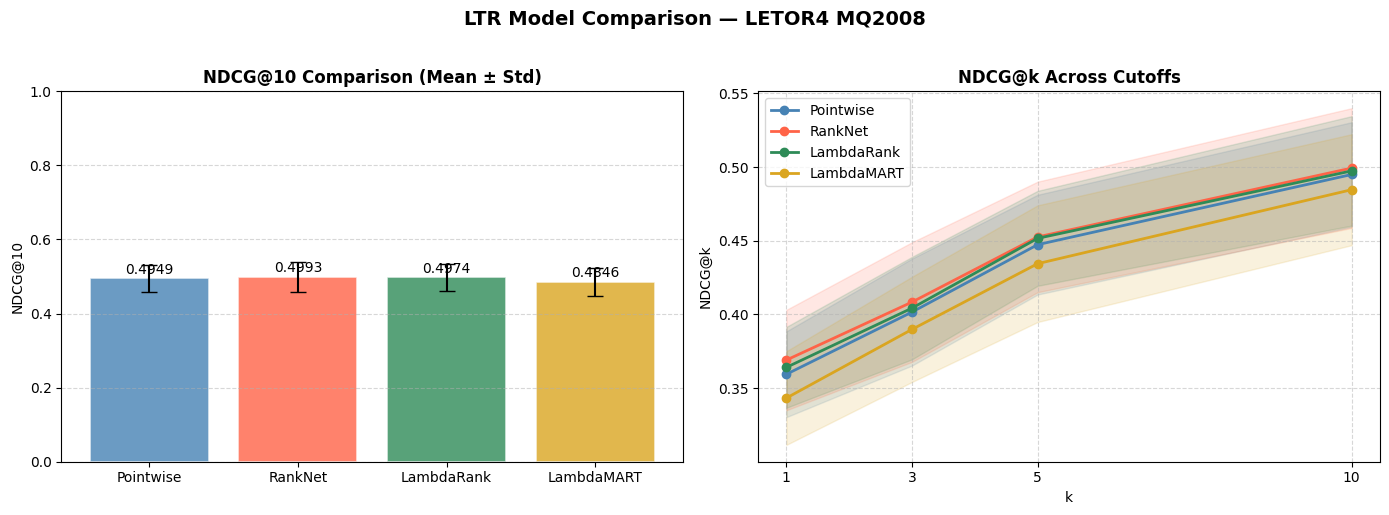

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_info = {
    "Pointwise":  (pointwise_results,  "steelblue"),
    "RankNet":    (ranknet_results,     "tomato"),
    "LambdaRank": (lambdarank_results,  "seagreen"),
    "LambdaMART": (lambdamart_results, "goldenrod")
}

# ── Left: Bar chart of NDCG@10 ───────────────────────────────────────────────
ax = axes[0]
names  = list(models_info.keys())
means  = []
stds   = []
colors = []

for name, (res, color) in models_info.items():
    overall = res.get("overall", {})
    entry   = overall.get("10", overall.get(10, {"mean": 0.0, "std": 0.0}))
    means.append(entry["mean"])
    stds.append(entry["std"])
    colors.append(color)

bars = ax.bar(names, means, yerr=stds, color=colors, alpha=0.8,
              capsize=6, edgecolor="white", linewidth=1.2)
ax.set_ylabel("NDCG@10")
ax.set_title("NDCG@10 Comparison (Mean ± Std)", fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.5)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=10)

# ── Right: Line chart across k values ────────────────────────────────────────
ax = axes[1]
for name, (res, color) in models_info.items():
    overall = res.get("overall", {})
    y_means = []
    y_stds  = []
    for k in K_LIST:
        entry = overall.get(str(k), overall.get(k, {"mean": 0.0, "std": 0.0}))
        y_means.append(entry["mean"])
        y_stds.append(entry["std"])
    ax.plot(K_LIST, y_means, marker="o", label=name, color=color, linewidth=2)
    ax.fill_between(K_LIST,
                    [m - s for m, s in zip(y_means, y_stds)],
                    [m + s for m, s in zip(y_means, y_stds)],
                    alpha=0.15, color=color)

ax.set_xlabel("k")
ax.set_ylabel("NDCG@k")
ax.set_title("NDCG@k Across Cutoffs", fontweight="bold")
ax.set_xticks(K_LIST)
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

plt.suptitle("LTR Model Comparison — LETOR4 MQ2008", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Results — Visual Analysis  

The bar chart (left) shows NDCG@10 with error bars (±std). The line chart (right) shows performance across all cutoffs k ∈ {1, 3, 5, 10}.
1. The NDCG at larger K is converged for all models which means for larger k we can just use a regressor model which is simple and good at retrieving documents.

## Step 4 · Statistical Significance Testing

We use a **paired t-test** (`scipy.stats.ttest_rel`) on the raw per-query NDCG@10
arrays from the 5-fold evaluation.  Because each fold produces a fixed set of test
queries evaluated by all models, the data is naturally paired.

A **p-value < 0.05** indicates the difference between two models is statistically
significant at the 5% level.


In [14]:
# Flatten per-query NDCG@10 values from all folds and seeds
def extract_per_query_ndcg10(results: dict, k: int = 10) -> list:
    """
    Extract a flat list of per-seed mean NDCG@k values across all folds.
    These serve as the paired observations for the t-test.
    """
    values = []
    for fold_res in results.get("fold_results", []):
        for seed_res in fold_res.get("per_seed", []):
            key = str(k) if str(k) in seed_res else k
            values.append(seed_res.get(key, seed_res.get(str(key), 0.0)))
    return values

pw_scores  = extract_per_query_ndcg10(pointwise_results,  k=10)
rn_scores  = extract_per_query_ndcg10(ranknet_results,    k=10)
lr_scores  = extract_per_query_ndcg10(lambdarank_results,  k=10)
lm_scores  = extract_per_query_ndcg10(lambdamart_results, k=10)

print(f"Observations per model: {len(pw_scores)} (folds × seeds)")
print()

pairs = [
    ("Pointwise",  "RankNet",    pw_scores,  rn_scores),
    ("Pointwise",  "LambdaRank", pw_scores,  lr_scores),
    ("RankNet",    "LambdaRank", rn_scores,  lr_scores),
    ("LambdaMART", "LambdaRank", lm_scores, lr_scores),
]

print(f"{'─'*55}")
print(f"{'Comparison':<30}  {'p-value':>10}  {'Significant?':>12}")
print(f"{'─'*55}")
for name_a, name_b, a, b in pairs:
    p = paired_significance(a, b)
    sig = "✓ Yes" if p < 0.05 else "✗ No"
    label = f"{name_a} vs {name_b}"
    print(f"{label:<30}  {p:>10.4f}  {sig:>12}")
print(f"{'─'*55}")
print("(α = 0.05, two-tailed paired t-test)")


Observations per model: 15 (folds × seeds)

───────────────────────────────────────────────────────
Comparison                         p-value  Significant?
───────────────────────────────────────────────────────
Pointwise vs RankNet                0.0868          ✗ No
Pointwise vs LambdaRank             0.1626          ✗ No
RankNet vs LambdaRank               0.4786          ✗ No
LambdaMART vs LambdaRank            0.0038         ✓ Yes
───────────────────────────────────────────────────────
(α = 0.05, two-tailed paired t-test)


## Results:

- We cannot say which is the best model among Pointwise, Ranknet and LambdaRank.
- LambdaMART is the worse model becuase it overfits the current dataset

**Next Steps**:- Train these models with a larger dataset like MSLR. So that we can come to a conlusion.

## Step 5 · Per-Fold NDCG@10 Summary

In [15]:
import pandas as pd

rows = []
for mode, results in [("Pointwise", pointwise_results),
                       ("RankNet",   ranknet_results),
                       ("LambdaRank",lambdarank_results),
                       ("LambdaMART",lambdamart_results)]:
    for fold_res in results.get("fold_results", []):
        fold_num = fold_res["fold"]
        summary  = fold_res["summary"]
        key = "10" if "10" in summary else 10
        entry = summary.get(key, {"mean": 0.0, "std": 0.0})
        rows.append({
            "Model": mode,
            "Fold":  fold_num,
            "NDCG@10 Mean": round(entry["mean"], 4),
            "NDCG@10 Std":  round(entry["std"],  4),
        })

df = pd.DataFrame(rows).pivot(index="Fold", columns="Model", values="NDCG@10 Mean")
print(df.to_string())
print()
print("Overall Mean:")
print(df.mean().to_string())


Model  LambdaMART  LambdaRank  Pointwise  RankNet
Fold                                             
1          0.4682      0.4726     0.4771   0.4720
2          0.4411      0.4478     0.4467   0.4506
3          0.4558      0.4887     0.4805   0.4789
4          0.5268      0.5461     0.5425   0.5508
5          0.5312      0.5319     0.5280   0.5442

Overall Mean:
Model
LambdaMART    0.48462
LambdaRank    0.49742
Pointwise     0.49496
RankNet       0.49930


## Results — Per-Fold Breakdown

- Folds where all three models perform similarly
   - It says that the test set contains all easy or hard queries where either a simple model is enough or Every model fails.
- Large gaps on a specific fold
   - This indicates that the test set contain medium difficulty queries where a good model performs well and simple model fails, this is the fold that we should consider for judging a model.

Fold 3,4,5 - these are the folds we should look for  
3 - LambdaRank   
4 - Ranknet(with a less difference)   
5 - Ranknet(with a good difference)  

- LambdaMART performed the worst in every fold due to overfitting.

## Conclusion

This notebook provides a fair, statistically grounded comparison of all three LTR approaches
on the standard LETOR4 / MQ2008 benchmark:

- **Same network** (`ScoringMLP`) for all three modes.
- **Same 5 author-provided folds**.
- **3 random seeds per fold**
- **Paired t-test**


-  From the results, we still cannot say that which is better among Ranknet, LambdaRank. We need a better dataset for the comparision where we can get high variance.